# Analise das metricas dos resultados

Este notebook consolida as metricas geradas em `outputs/metrics/` e os artefatos auxiliares dos experimentos para comparar modelos, horizontes e estabilidade entre treino, validacao e teste.

Escopo principal:

- comparar os modelos principais no split de `teste`;
- inspecionar estabilidade entre `treino`, `val` e `teste`;
- aproveitar `yearly_h30.csv` e `cv_summary.csv` quando esses arquivos existirem.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [2]:
ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = ROOT.parent

METRICS_DIR = ROOT / "outputs" / "metrics"
OUTPUTS_DIR = ROOT / "outputs"

DISPLAY_NAMES = {
    "baseline_lr": "Baseline LR",
    "xgboost": "XGBoost",
    "gru": "GRU",
    "cnn": "CNN",
    "lstm": "LSTM",
    "lstm_cv": "LSTM CV",
}

METRIC_COLUMNS = ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]

metric_files = sorted(METRICS_DIR.glob("metrics_*.csv"))
metric_files

[PosixPath('/home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_baseline_lr.csv'),
 PosixPath('/home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_cnn.csv'),
 PosixPath('/home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_gru.csv'),
 PosixPath('/home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_lstm.csv'),
 PosixPath('/home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_lstm_cv.csv'),
 PosixPath('/home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_xgboost.csv')]

In [3]:
def load_metrics(files: list[Path]) -> pd.DataFrame:
    frames = []
    for path in files:
        df = pd.read_csv(path)
        if "model" not in df.columns:
            inferred = path.stem.replace("metrics_", "")
            df["model"] = inferred
        df["source_file"] = path.name
        frames.append(df)

    metrics = pd.concat(frames, ignore_index=True)
    metrics["model_label"] = metrics["model"].map(DISPLAY_NAMES).fillna(metrics["model"])
    metrics["h"] = metrics["h"].astype(int)
    return metrics.sort_values(["model_label", "split", "h"]).reset_index(drop=True)


metrics = load_metrics(metric_files)
metrics.head()

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive,model,source_file,model_label
0,teste,5,38.234254,48.196797,1.823122,52.540273,1.159890,baseline_lr,metrics_baseline_lr.csv,Baseline LR
1,teste,15,63.872080,80.216165,3.054797,55.018587,1.067650,baseline_lr,metrics_baseline_lr.csv,Baseline LR
2,teste,30,87.658247,109.088709,4.155295,58.364312,1.002088,baseline_lr,metrics_baseline_lr.csv,Baseline LR
3,treino,5,15.456316,21.964455,1.591755,67.356093,0.820130,baseline_lr,metrics_baseline_lr.csv,Baseline LR
4,treino,15,26.963981,37.472007,2.761160,66.907550,0.820198,baseline_lr,metrics_baseline_lr.csv,Baseline LR


## Inventario de metricas

Primeiro confirmamos quais modelos e splits estao presentes para evitar comparar arquivos heterogeneos sem perceber.

In [4]:
inventory = (
    metrics.groupby(["model_label", "split"])["h"]
    .apply(lambda s: ", ".join(map(str, sorted(s.unique()))))
    .rename("horizons")
    .reset_index()
)
inventory

,model_label,split,horizons
0,Baseline LR,teste,"5, 15, 30"
1,Baseline LR,treino,"5, 15, 30"
2,Baseline LR,val,"5, 15, 30"
3,CNN,teste,"5, 15, 30"
4,GRU,teste,"5, 15, 30"
5,GRU,treino,"5, 15, 30"
6,GRU,val,"5, 15, 30"
7,LSTM,teste,"5, 15, 30"
8,LSTM,treino,"5, 15, 30"
9,LSTM,val,"5, 15, 30"


In [5]:
core_models = ["baseline_lr", "xgboost", "gru", "cnn", "lstm"]
core = metrics[metrics["model"].isin(core_models)].copy()
variants = metrics[~metrics["model"].isin(core_models)].copy()

display(Markdown(f"**Modelos principais:** {', '.join(core['model_label'].unique())}"))
if not variants.empty:
    display(Markdown(f"**Variantes separadas do comparativo principal:** {', '.join(variants['model_label'].unique())}"))

**Modelos principais:** Baseline LR, CNN, GRU, LSTM, XGBoost

**Variantes separadas do comparativo principal:** LSTM CV

## Comparativo principal no split de teste

Este e o comparativo mais direto entre os modelos principais. Quanto menor `MAE`, `RMSE`, `MAPE%` e `MAE/naive`, melhor. Quanto maior `DirAcc%`, melhor.

In [6]:
test_core = core[core["split"] == "teste"].copy()
test_core = test_core.sort_values(["h", "model_label"]).reset_index(drop=True)
test_core

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive,model,source_file,model_label
0,teste,5,38.234254,48.196797,1.823122,52.540273,1.159890,baseline_lr,metrics_baseline_lr.csv,Baseline LR
1,teste,5,32.388161,41.415163,1.555198,57.372986,0.982540,cnn,metrics_cnn.csv,CNN
2,teste,5,32.645048,41.773119,1.566294,53.407683,0.990333,gru,metrics_gru.csv,GRU
3,teste,5,32.615607,41.499812,1.567165,53.283767,0.989440,lstm,metrics_lstm.csv,LSTM
4,teste,5,32.532817,41.619450,1.561736,56.505576,0.986929,xgboost,metrics_xgboost.csv,XGBoost
5,teste,15,63.872080,80.216165,3.054797,55.018587,1.067650,baseline_lr,metrics_baseline_lr.csv,Baseline LR
6,teste,15,58.081333,72.680149,2.774406,58.859975,0.970855,cnn,metrics_cnn.csv,CNN
7,teste,15,59.559013,74.359622,2.837055,56.505576,0.995555,gru,metrics_gru.csv,GRU
8,teste,15,58.483059,73.232101,2.779673,54.770756,0.977570,lstm,metrics_lstm.csv,LSTM
9,teste,15,58.257675,73.110178,2.778680,58.859975,0.973803,xgboost,metrics_xgboost.csv,XGBoost


In [7]:
test_pivot = (
    test_core.pivot_table(
        index=["model_label"],
        columns="h",
        values=METRIC_COLUMNS,
    )
    .sort_index(axis=1, level=[0, 1])
)
test_pivot.round(3)

DirAcc%                     MAE                 MAE/naive         \
h                5       15      30      5       15      30        5      15   
model_label                                                                    
Baseline LR  52.540  55.019  58.364  38.234  63.872  87.658     1.160  1.068   
CNN          57.373  58.860  61.958  32.388  58.081  83.434     0.983  0.971   
GRU          53.408  56.506  58.736  32.645  59.559  85.001     0.990  0.996   
LSTM         53.284  54.771  57.621  32.616  58.483  85.766     0.989  0.978   
XGBoost      56.506  58.860  61.958  32.533  58.258  83.156     0.987  0.974   

                    MAPE%                  RMSE                   
h               30     5      15     30      5       15       30  
model_label                                                       
Baseline LR  1.002  1.823  3.055  4.155  48.197  80.216  109.089  
CNN          0.954  1.555  2.774  3.918  41.415  72.680  102.378  
GRU          0.972  1.566  2.837  3.971  41.773  74.360  103.698  
LSTM         0.980  1.567  2.780  4.015  41.500  73.232  103.494  
XGBoost      0.951  1.562  2.779  3.892  41.619  73.110  101.450

In [8]:
rank_frames = []
for metric_name, ascending in {
    "MAE": True,
    "RMSE": True,
    "MAPE%": True,
    "MAE/naive": True,
    "DirAcc%": False,
}.items():
    temp = test_core[["model_label", "h", metric_name]].copy()
    temp["rank"] = temp.groupby("h")[metric_name].rank(method="min", ascending=ascending)
    summary = temp.groupby("model_label")["rank"].mean().rename(metric_name)
    rank_frames.append(summary)

rank_table = pd.concat(rank_frames, axis=1)
rank_table["rank_medio"] = rank_table.mean(axis=1)
rank_table.sort_values("rank_medio").round(2)

,MAE,RMSE,MAPE%,MAE/naive,DirAcc%,rank_medio
model_label,,,,,,
CNN,1.33,1.33,1.33,1.33,1.00,1.27
XGBoost,1.67,2.00,1.67,1.67,1.33,1.67
GRU,3.67,4.00,3.33,3.67,3.00,3.53
LSTM,3.33,2.67,3.67,3.33,4.67,3.53
Baseline LR,5.00,5.00,5.00,5.00,4.33,4.87


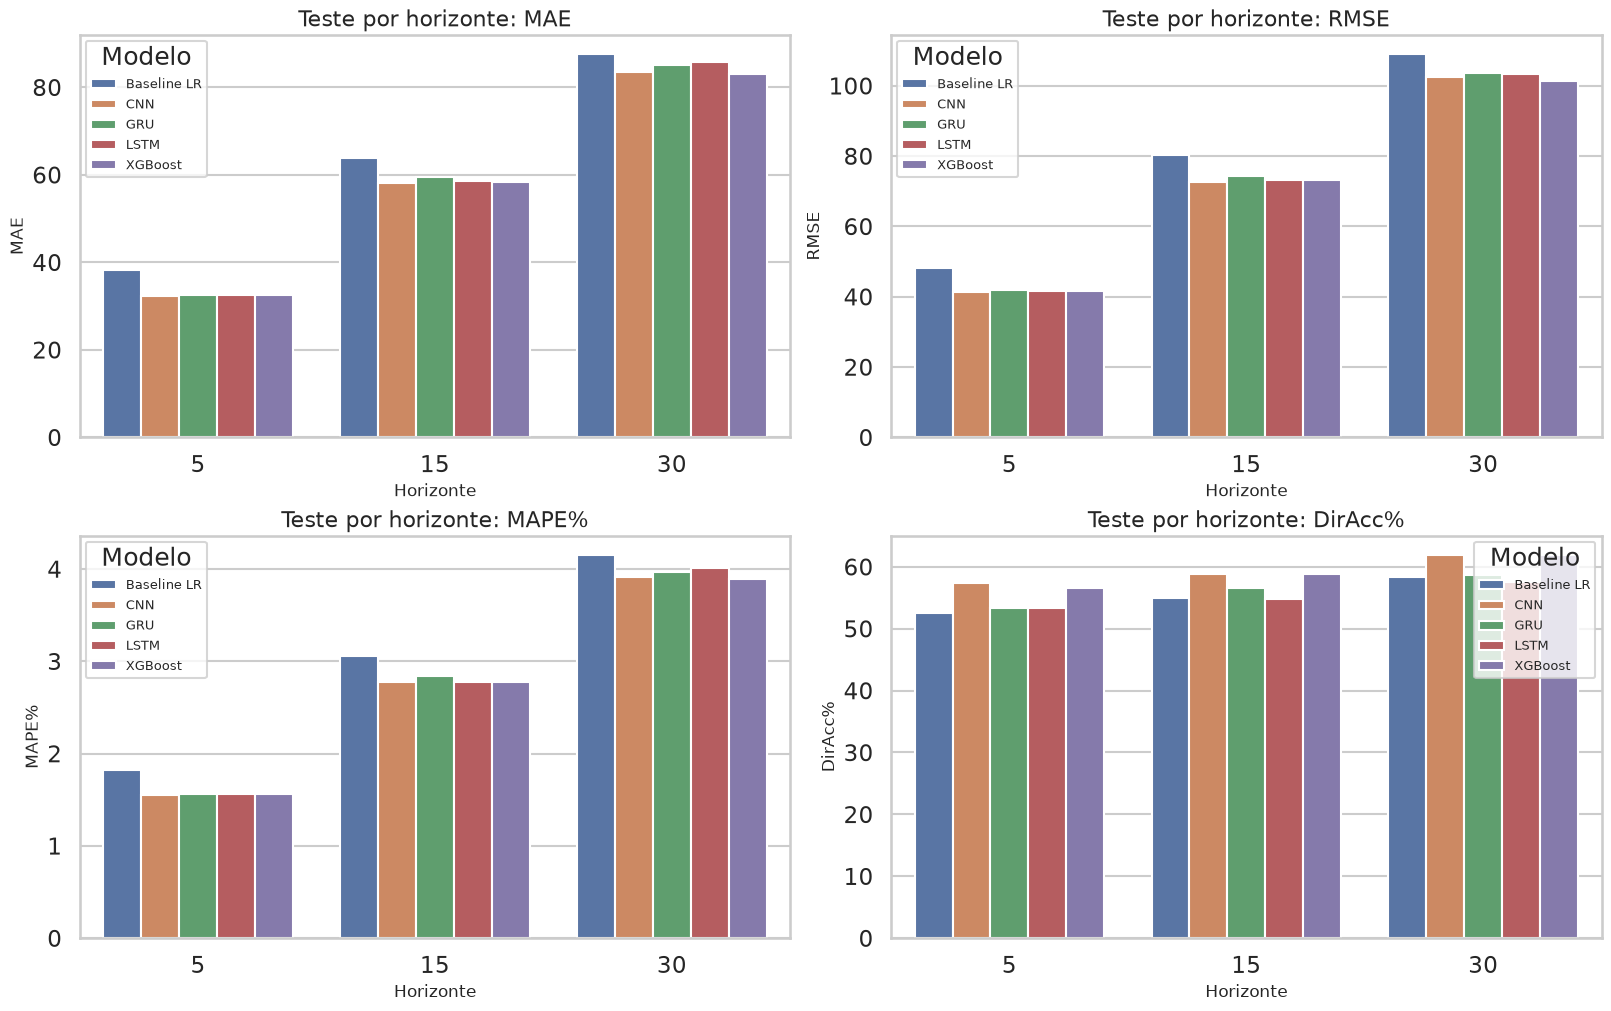

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
plots = [
    ("MAE", True),
    ("RMSE", True),
    ("MAPE%", True),
    ("DirAcc%", False),
]

for ax, (metric_name, _) in zip(axes.flat, plots):
    sns.barplot(data=test_core, x="h", y=metric_name, hue="model_label", ax=ax)
    ax.set_title(f"Teste por horizonte: {metric_name}")
    ax.set_xlabel("Horizonte")
    ax.set_ylabel(metric_name)
    ax.legend(title="Modelo", fontsize=9)

plt.show()

## Estabilidade por split

Aqui a pergunta muda: em vez de procurar apenas o melhor resultado de teste, observamos o quanto cada modelo se desloca entre treino, validacao e teste.

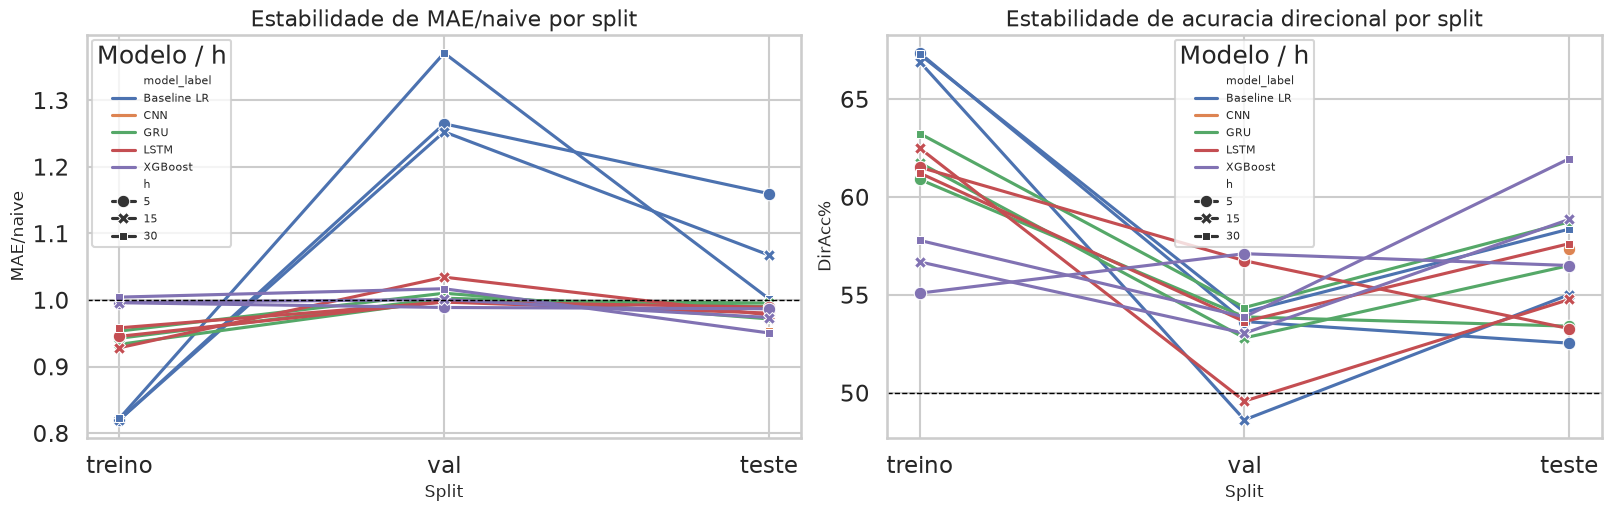

In [10]:
split_order = ["treino", "val", "teste"]
split_core = core[core["split"].isin(split_order)].copy()
split_core["split"] = pd.Categorical(split_core["split"], categories=split_order, ordered=True)
split_core = split_core.sort_values(["model_label", "h", "split"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.lineplot(data=split_core, x="split", y="MAE/naive", hue="model_label", style="h", markers=True, dashes=False, ax=axes[0])
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Estabilidade de MAE/naive por split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("MAE/naive")

sns.lineplot(data=split_core, x="split", y="DirAcc%", hue="model_label", style="h", markers=True, dashes=False, ax=axes[1])
axes[1].axhline(50.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Estabilidade de acuracia direcional por split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("DirAcc%")

for ax in axes:
    ax.legend(title="Modelo / h", fontsize=8)

plt.show()

In [11]:
generalization_gap = (
    split_core.pivot_table(index=["model_label", "h"], columns="split", values=["MAE/naive", "DirAcc%"])
)

generalization_gap[("gap_MAE/naive", "teste-menos-treino")] = generalization_gap[("MAE/naive", "teste")] - generalization_gap[("MAE/naive", "treino")]
generalization_gap[("gap_DirAcc", "teste-menos-treino")] = generalization_gap[("DirAcc%", "teste")] - generalization_gap[("DirAcc%", "treino")]
generalization_gap.sort_index(axis=1).round(3)

DirAcc%                 MAE/naive                \
split            teste  treino     val     teste treino    val   
model_label h                                                    
Baseline LR 5   52.540  67.356  53.644     1.160  0.820  1.265   
            15  55.019  66.908  48.626     1.068  0.820  1.253   
            30  58.364  67.281  54.122     1.002  0.822  1.371   
CNN         5   57.373     NaN     NaN     0.983    NaN    NaN   
            15  58.860     NaN     NaN     0.971    NaN    NaN   
            30  61.958     NaN     NaN     0.954    NaN    NaN   
GRU         5   53.408  60.902  53.883     0.990  0.943  1.003   
            15  56.506  61.749  52.808     0.996  0.933  1.000   
            30  58.736  63.244  54.361     0.972  0.953  1.010   
LSTM        5   53.284  61.525  56.750     0.989  0.946  0.997   
            15  54.771  62.497  49.582     0.978  0.928  1.034   
            30  57.621  61.226  53.644     0.980  0.958  0.997   
XGBoost     5   56.506  55.096  57.109     0.987  0.996  0.989   
            15  58.860  56.691  53.047     0.974  0.996  1.001   
            30  61.958  57.787  53.883     0.951  1.004  1.017   

                       gap_DirAcc      gap_MAE/naive  
split          teste-menos-treino teste-menos-treino  
model_label h                                         
Baseline LR 5             -14.816              0.340  
            15            -11.889              0.247  
            30             -8.917              0.180  
CNN         5                 NaN                NaN  
            15                NaN                NaN  
            30                NaN                NaN  
GRU         5              -7.494              0.048  
            15             -5.244              0.062  
            30             -4.508              0.018  
LSTM        5              -8.241              0.044  
            15             -7.726              0.049  
            30             -3.605              0.022  
XGBoost     5               1.410             -0.009  
            15              2.169             -0.022  
            30              4.171             -0.054

## Analise anual em `h=30`

Os arquivos `yearly_h30.csv` mostram como o desempenho muda ao longo do tempo para o horizonte mais longo.

In [12]:
def load_yearly_h30(outputs_dir: Path) -> pd.DataFrame:
    frames = []
    mapping = {
        "02_xgboost": "xgboost",
        "03_gru": "gru",
        "04_cnn": "cnn",
        "05_lstm": "lstm",
    }
    for folder, model in mapping.items():
        path = outputs_dir / folder / "yearly_h30.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if "ano" in df.columns:
            df = df.rename(columns={"ano": "year"})
        elif "year" not in df.columns:
            df = df.rename_axis("year").reset_index()
        df["model"] = model
        df["model_label"] = DISPLAY_NAMES[model]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, ignore_index=True)
    result["year"] = result["year"].astype(int)
    return result.sort_values(["year", "model_label"]).reset_index(drop=True)


yearly_h30 = load_yearly_h30(OUTPUTS_DIR)
yearly_h30.head()

,year,DirAcc%,MAE/naive,model,model_label
0,2021,84.615385,0.541554,cnn,CNN
1,2021,76.923077,0.560200,gru,GRU
2,2021,30.769231,1.485644,lstm,LSTM
3,2021,84.615385,0.552991,xgboost,XGBoost
4,2022,45.816733,1.049099,cnn,CNN


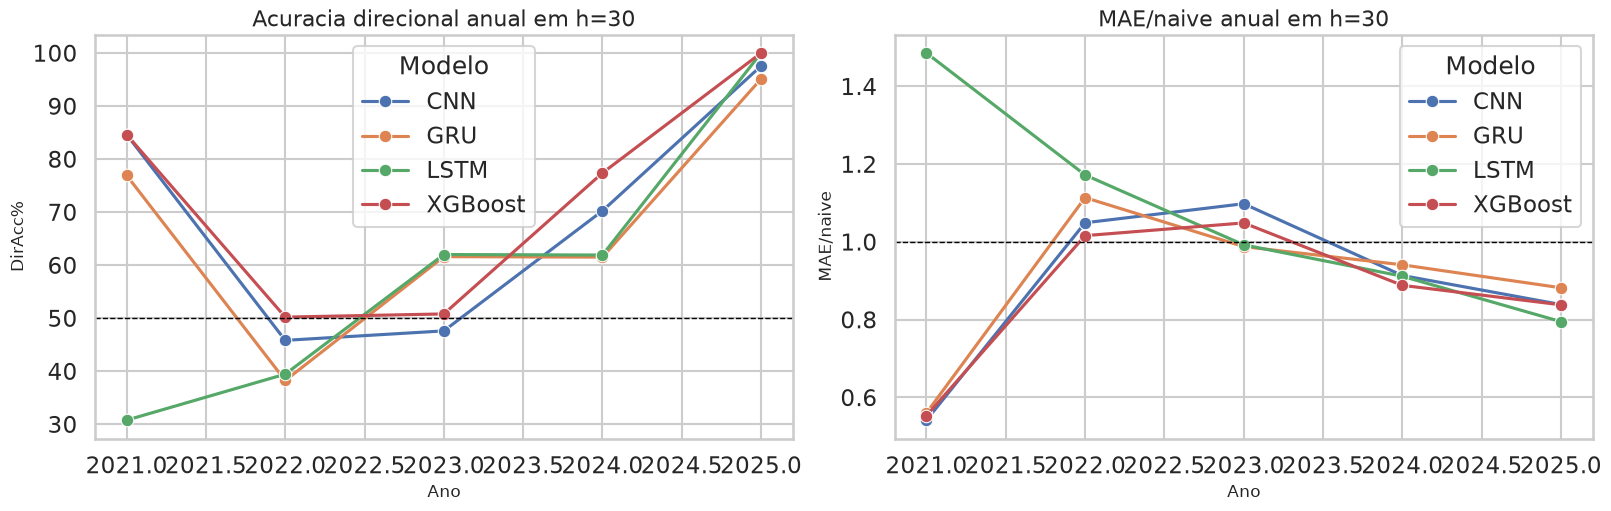

,year,DirAcc%,MAE/naive,model,model_label
0,2021,84.615,0.542,cnn,CNN
1,2021,76.923,0.560,gru,GRU
2,2021,30.769,1.486,lstm,LSTM
3,2021,84.615,0.553,xgboost,XGBoost
4,2022,45.817,1.049,cnn,CNN
5,2022,38.247,1.114,gru,GRU
6,2022,39.442,1.172,lstm,LSTM
7,2022,50.199,1.016,xgboost,XGBoost
8,2023,47.600,1.098,cnn,CNN
9,2023,61.600,0.988,gru,GRU


In [13]:
if yearly_h30.empty:
    display(Markdown("Nenhum arquivo `yearly_h30.csv` encontrado."))
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    sns.lineplot(data=yearly_h30, x="year", y="DirAcc%", hue="model_label", marker="o", ax=axes[0])
    axes[0].axhline(50.0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Acuracia direcional anual em h=30")
    axes[0].set_xlabel("Ano")
    axes[0].set_ylabel("DirAcc%")

    sns.lineplot(data=yearly_h30, x="year", y="MAE/naive", hue="model_label", marker="o", ax=axes[1])
    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("MAE/naive anual em h=30")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("MAE/naive")

    for ax in axes:
        ax.legend(title="Modelo")

    plt.show()
    display(yearly_h30.round(3))

## Resumo de validacao cruzada

Alguns experimentos salvaram `cv_summary.csv`. Esses arquivos nao substituem o teste final, mas ajudam a comparar media e desvio-padrao da fase de validacao.

In [14]:
def load_cv_summary(outputs_dir: Path) -> pd.DataFrame:
    frames = []
    mapping = {
        "03_gru": "gru",
        "04_cnn": "cnn",
        "05_lstm": "lstm",
    }
    for folder, model in mapping.items():
        path = outputs_dir / folder / "cv_summary.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path, header=[0, 1], index_col=0)
        df.index.name = "h"
        flat_columns = []
        for metric_name, stat_name in df.columns:
            metric_name = str(metric_name).strip()
            stat_name = str(stat_name).strip()
            flat_columns.append(f"{metric_name}_{stat_name}")
        df.columns = flat_columns
        df = df.reset_index()
        df["model"] = model
        df["model_label"] = DISPLAY_NAMES[model]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, ignore_index=True)
    result["h"] = result["h"].astype(int)
    return result.sort_values(["h", "model_label"]).reset_index(drop=True)


cv_summary = load_cv_summary(OUTPUTS_DIR)
cv_summary.head()

,h,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE%_mean,MAPE%_std,DirAcc%_mean,DirAcc%_std,MAE/naive_mean,MAE/naive_std,model,model_label
0,5,22.429,5.610,30.624,8.412,1.908,0.380,55.261,5.667,0.995,0.024,cnn,CNN
1,5,23.515,6.054,32.062,9.132,1.991,0.389,51.470,2.027,1.042,0.038,gru,GRU
2,5,23.654,6.263,32.108,9.362,2.007,0.426,51.373,3.961,1.048,0.047,lstm,LSTM
3,15,39.082,10.275,51.431,13.549,3.312,0.622,54.751,8.417,1.006,0.055,cnn,CNN
4,15,40.634,10.816,52.880,13.913,3.436,0.644,53.900,6.564,1.047,0.067,gru,GRU


,h,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE%_mean,MAPE%_std,DirAcc%_mean,DirAcc%_std,MAE/naive_mean,MAE/naive_std,model,model_label,MAE,RMSE,MAPE%,DirAcc%,MAE/naive,MAE_delta_test_minus_cvmean,DirAcc_delta_test_minus_cvmean
0,5,22.429,5.610,30.624,8.412,1.908,0.380,55.261,5.667,0.995,0.024,cnn,CNN,32.388,41.415,1.555,57.373,0.983,9.959,2.112
1,5,23.515,6.054,32.062,9.132,1.991,0.389,51.470,2.027,1.042,0.038,gru,GRU,32.645,41.773,1.566,53.408,0.990,9.130,1.938
2,5,23.654,6.263,32.108,9.362,2.007,0.426,51.373,3.961,1.048,0.047,lstm,LSTM,32.616,41.500,1.567,53.284,0.989,8.962,1.911
3,15,39.082,10.275,51.431,13.549,3.312,0.622,54.751,8.417,1.006,0.055,cnn,CNN,58.081,72.680,2.774,58.860,0.971,18.999,4.109
4,15,40.634,10.816,52.880,13.913,3.436,0.644,53.900,6.564,1.047,0.067,gru,GRU,59.559,74.360,2.837,56.506,0.996,18.925,2.606
5,15,40.658,10.493,53.229,13.725,3.418,0.577,55.067,4.546,1.049,0.068,lstm,LSTM,58.483,73.232,2.780,54.771,0.978,17.825,-0.296
6,30,55.879,16.790,71.006,19.294,4.660,0.836,54.775,13.865,1.037,0.138,cnn,CNN,83.434,102.378,3.918,61.958,0.954,27.555,7.183
7,30,57.873,20.326,74.114,24.447,4.789,0.963,58.080,12.110,1.074,0.225,gru,GRU,85.001,103.698,3.971,58.736,0.972,27.128,0.656
8,30,57.302,16.956,72.127,19.289,4.831,0.927,55.917,10.651,1.075,0.193,lstm,LSTM,85.766,103.494,4.015,57.621,0.980,28.464,1.704


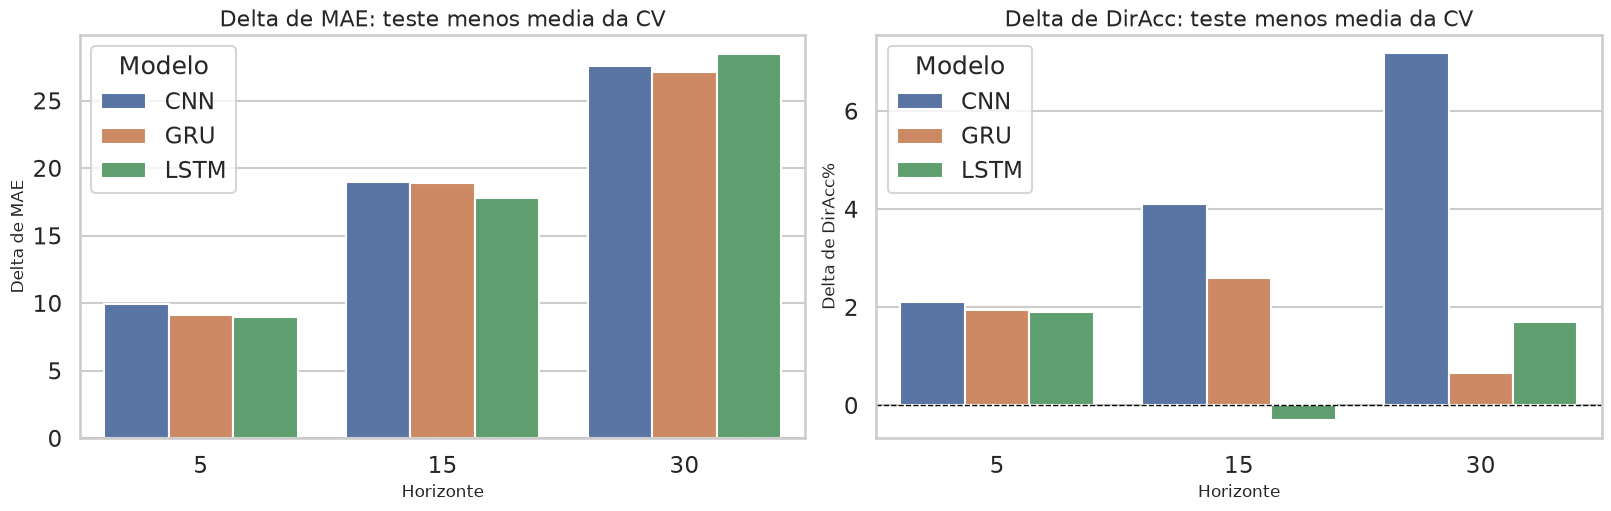

In [15]:
if cv_summary.empty:
    display(Markdown("Nenhum `cv_summary.csv` encontrado."))
else:
    comparison = cv_summary.merge(
        test_core[["model", "h", "MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]],
        on=["model", "h"],
        suffixes=("_cv_mean", "_test"),
    )
    comparison["MAE_delta_test_minus_cvmean"] = comparison["MAE"] - comparison["MAE_mean"]
    comparison["DirAcc_delta_test_minus_cvmean"] = comparison["DirAcc%"] - comparison["DirAcc%_mean"]
    display(comparison.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    sns.barplot(data=comparison, x="h", y="MAE_delta_test_minus_cvmean", hue="model_label", ax=axes[0])
    axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Delta de MAE: teste menos media da CV")
    axes[0].set_xlabel("Horizonte")
    axes[0].set_ylabel("Delta de MAE")

    sns.barplot(data=comparison, x="h", y="DirAcc_delta_test_minus_cvmean", hue="model_label", ax=axes[1])
    axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Delta de DirAcc: teste menos media da CV")
    axes[1].set_xlabel("Horizonte")
    axes[1].set_ylabel("Delta de DirAcc%")

    for ax in axes:
        ax.legend(title="Modelo")

    plt.show()

## Variantes fora do comparativo principal

Arquivos como `metrics_lstm_cv.csv` podem representar fluxos auxiliares ou variantes experimentais. Eles ficam separados para nao contaminar o ranking principal.

In [16]:
if variants.empty:
    display(Markdown("Nenhuma variante adicional encontrada."))
else:
    display(variants.round(3))

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive,model,source_file,model_label
30,teste,5,34.520,44.161,1.663,51.673,1.047,lstm_cv,metrics_lstm_cv.csv,LSTM CV
31,teste,15,61.274,76.564,2.933,54.771,1.024,lstm_cv,metrics_lstm_cv.csv,LSTM CV
32,teste,30,86.784,111.149,4.082,56.382,0.992,lstm_cv,metrics_lstm_cv.csv,LSTM CV
33,treino+val,5,18.110,26.949,1.697,64.028,0.916,lstm_cv,metrics_lstm_cv.csv,LSTM CV
34,treino+val,15,30.401,43.880,2.828,68.543,0.894,lstm_cv,metrics_lstm_cv.csv,LSTM CV
35,treino+val,30,44.308,60.990,4.104,65.061,0.940,lstm_cv,metrics_lstm_cv.csv,LSTM CV


## Leituras sugeridas

- use `rank_medio` como uma triagem inicial, nao como verdade absoluta;
- priorize `MAE/naive` e `DirAcc%` para interpretar utilidade pratica;
- sempre confirme se o melhor resultado em `teste` tambem parece estavel ao longo dos splits e, quando disponivel, por ano em `h=30`.